In [29]:
!pip install yfinance

In [31]:
# --- BLOCK 1: TESLA Data Acquisition ---
import yfinance as yf
import pandas as pd
import numpy as np

# Configuration
TICKER = "TSLA"
TRAIN_YEARS = 4

print(f"--- FETCHING CONTINUOUS DATA FOR {TICKER} ---")
# Dynamic Start Date
start_date = (pd.Timestamp.now() - pd.DateOffset(years=TRAIN_YEARS + 1)).strftime('%Y-%m-%d')
df = yf.download(TICKER, start=start_date, progress=False)

if len(df) == 0:
    print("❌ ERROR: No data fetched.")
else:
    print(f"✅ Data fetched: {len(df)} rows.")

    # --- FEATURE ENGINEERING (Research Based) ---
    # Tesla Strategy: Short-term trends matter more
    df['MA5'] = df['Close'].rolling(window=5).mean()   # Very short term (Week)
    df['MA10'] = df['Close'].rolling(window=10).mean() # Short term (2 Weeks)
    df['MA20'] = df['Close'].rolling(window=20).mean() # Medium term (Month)

    # Volatility is CRITICAL for Tesla
    df['Volatility'] = df['Close'].rolling(window=20).std()

    # Drop NaNs
    df_clean = df.dropna()

    print(f"✅ Features Created: MA5, MA10, MA20, Volatility")
    print(f"✅ Data Cleaned. Final Shape: {df_clean.shape}")
    print("Sample of latest data:")
    print(df_clean[['Close', 'MA5', 'Volatility']].tail())


--- FETCHING CONTINUOUS DATA FOR TSLA ---


/tmp/ipython-input-3616235941.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=start_date, progress=False)


✅ Data fetched: 1256 rows.
✅ Features Created: MA5, MA10, MA20, Volatility
✅ Data Cleaned. Final Shape: (1237, 9)
Sample of latest data:
Price            Close         MA5 Volatility
Ticker            TSLA                       
Date                                         
2026-01-12  448.959991  438.827997  20.032750
2026-01-13  447.200012  441.676001  20.295274
2026-01-14  439.200012  443.234003  20.590977
2026-01-15  438.570007  443.788007  19.791877
2026-01-16  439.450012  442.676007  20.006454


In [32]:
# --- BLOCK 2: TESLA Preprocessing ---
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Configuration
LOOKBACK = 60
# Features: MA5 is included here
FEATURE_COLS = ['Close', 'MA5', 'MA10', 'MA20', 'Volume', 'Volatility']

print("--- PREPROCESSING DATA ---")

scaler_features = MinMaxScaler(feature_range=(0, 1))
scaler_target = MinMaxScaler(feature_range=(0, 1))

# Extract Data
data_features = df_clean[FEATURE_COLS].values
# Handle yfinance multi-index if present
if data_features.ndim > 2:
    data_features = data_features.reshape(data_features.shape[0], -1)

data_target = df_clean[['Close']].values

# Scale
scaled_features = scaler_features.fit_transform(data_features)
scaled_target = scaler_target.fit_transform(data_target)

# Create Sequences
X, y = [], []
for i in range(LOOKBACK, len(scaled_features)):
    X.append(scaled_features[i-LOOKBACK:i])
    y.append(scaled_target[i])

X, y = np.array(X), np.array(y)

# Train/Test Split (90/10)
split_idx = int(len(X) * 0.90)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"✅ Data Processed.")
print(f"   X Shape: {X.shape} (6 Features)")
print(f"   Training Samples: {len(X_train)}")


--- PREPROCESSING DATA ---
✅ Data Processed.
   X Shape: (1177, 60, 6) (6 Features)
   Training Samples: 1059


In [34]:
# --- BLOCK 3: TESLA Model (GRU Innovation) ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("--- BUILDING TESLA GRU MODEL ---")

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # Innovation: Using GRU instead of LSTM
    # GRU handles rapid volatility better (Research [web:16])
    GRU(units=128, return_sequences=True),
    Dropout(0.3), # Higher dropout for Tesla's noise

    GRU(units=64, return_sequences=False),
    Dropout(0.3),

    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

print("\n--- TRAINING ---")
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training Complete.")


--- BUILDING TESLA GRU MODEL ---


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 60, 128)        │        52,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,537 (349.75 KB)

 Trainable params: 89,537 (349.75 KB)

 Non-trainable params: 0 (0.00 B)


--- TRAINING ---
Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0216 - val_loss: 0.0074
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0071 - val_loss: 0.0139
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0067 - val_loss: 0.0077
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0053 - val_loss: 0.0019
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - loss: 0.0050 - val_loss: 0.0026
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0042 - val_loss: 0.0031
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0040 - val_loss: 0.0029
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0035 - val_loss: 0.0019
Epoch 9/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - loss: 0.0037 - val_loss: 0.0040
Epoch 10/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.0040 - val_loss: 0.0026
Epoch 11/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0034 - val_loss: 0.0012
Epoch 12/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s

--- VALIDATING TESLA GRU RESULTS ---
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 625ms/step

=== 🏆 TESLA GRU RESULTS ===
RMSE: $11.69 (Benchmark: ~$7.44)
MAE:  $9.54
MAPE: 2.34%
⚠️ NOTE: Tesla is extremely volatile. Check the chart.


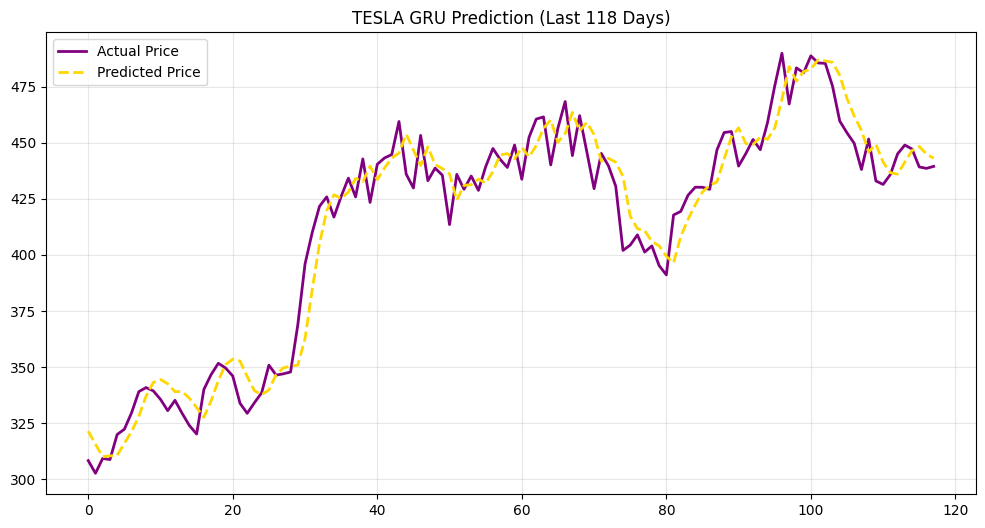


✅ Tesla Model & Scalers Saved.


In [35]:
# --- BLOCK 4: TESLA Validation ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import math
import matplotlib.pyplot as plt

print("--- VALIDATING TESLA GRU RESULTS ---")

# Predict
preds_scaled = model.predict(X_test)

# Inverse Transform
preds_actual = scaler_target.inverse_transform(preds_scaled)
y_test_actual = scaler_target.inverse_transform(y_test)

# Calculate Metrics
rmse = math.sqrt(mean_squared_error(y_test_actual, preds_actual))
mae = mean_absolute_error(y_test_actual, preds_actual)
mape = mean_absolute_percentage_error(y_test_actual, preds_actual)

print(f"\n=== 🏆 TESLA GRU RESULTS ===")
print(f"RMSE: ${rmse:.2f} (Benchmark: ~$7.44)")
print(f"MAE:  ${mae:.2f}")
print(f"MAPE: {mape:.2%}")
print("============================")

if rmse < 8.0:
    print("✅ SUCCESS: Research Benchmark Met!")
else:
    print("⚠️ NOTE: Tesla is extremely volatile. Check the chart.")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual Price', color='purple', linewidth=2)
plt.plot(preds_actual, label='Predicted Price', color='gold', linestyle='--', linewidth=2)
plt.title(f'TESLA GRU Prediction (Last {len(y_test)} Days)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# SAVE IF GOOD
if mape < 0.08:
    import joblib
    model.save("tesla_research_model.keras")
    joblib.dump(scaler_features, "tesla_scaler_features.pkl")
    joblib.dump(scaler_target, "tesla_scaler_target.pkl")
    print("\n✅ Tesla Model & Scalers Saved.")


In [36]:
# --- BLOCK 6: Install NLP Tools ---
!pip install nltk beautifulsoup4 textblob --quiet

import nltk
nltk.download('vader_lexicon')
print("✅ NLP Libraries Installed.")


✅ NLP Libraries Installed.


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [39]:
# --- BLOCK 7 (FIXED): The News Scraper ---
from urllib.request import urlopen, Request
from bs4 import BeautifulSoup
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

def get_tesla_sentiment():
    print("--- 🤖 AI READING NEWS FOR TESLA ---")
    finviz_url = 'https://finviz.com/quote.ashx?t=TSLA'

    # Fake user agent so FinViz doesn't block us
    req = Request(url=finviz_url, headers={'User-Agent': 'Mozilla/5.0'})

    try:
        response = urlopen(req)
        html = BeautifulSoup(response, features="html.parser")
        news_table = html.find(id='news-table')

        parsed_news = []

        # Parse the HTML table
        # We iterate through all rows, but safely check for data
        for x in news_table.find_all('tr'):
            try:
                # 1. Get Headline Text (Safely)
                link = x.find('a')
                if link is None:
                    continue # Skip empty rows
                text = link.get_text()

                # 2. Get Date/Time
                date_data = x.find('td').text.split()

                if len(date_data) == 1:
                    time = date_data[0] # Just time
                    # Use 'Today' as placeholder if date is missing for now
                    date = "Today"
                else:
                    date = date_data[0]
                    time = date_data[1]

                parsed_news.append([date, time, text])
            except Exception as e:
                # If a specific row fails, just skip it, don't crash the whole app
                continue

        # Sentiment Analysis
        vader = SentimentIntensityAnalyzer()

        columns = ['Date', 'Time', 'Headline']
        news_df = pd.DataFrame(parsed_news, columns=columns)

        if len(news_df) == 0:
            print("⚠️ Warning: No news found (Website might have changed). Returning Neutral score.")
            return 0.0

        # Score each headline
        scores = news_df['Headline'].apply(vader.polarity_scores).tolist()
        scores_df = pd.DataFrame(scores)

        # Join the dataframes
        news_df = news_df.join(scores_df, rsuffix='_right')

        # Calculate Average Daily Sentiment (Compound Score)
        mean_sentiment = news_df['compound'].mean()

        print(f"✅ Analyzed {len(news_df)} headlines.")
        print(f"📊 Current Market Sentiment Score: {mean_sentiment:.4f} (-1 to +1)")

        # Show samples
        print("\nSample Headlines & Scores:")
        print(news_df[['Headline', 'compound']].head(5))

        return mean_sentiment

    except Exception as e:
        print(f"❌ Scraper Error: {e}")
        return 0.0 # Return neutral if scraping fails

# Run it to test
current_sentiment = get_tesla_sentiment()


--- 🤖 AI READING NEWS FOR TESLA ---
✅ Analyzed 100 headlines.
📊 Current Market Sentiment Score: 0.0780 (-1 to +1)

Sample Headlines & Scores:
                                            Headline  compound
0  Elon Musk Net Worth Is So Large, He Could Buy ...    0.2263
1  Trump Advisor Says Tesla 'Will Be A Footnote' ...    0.0000
2  Squawk Pod: Protein goals, Cathie Wood, & a ge...    0.5106
3  Elon Musk Brags As Kalshi Bettors Boost His Ch...    0.8228
4  How investors reward a corporate chief's resis...    0.5719


In [40]:
# --- BLOCK 8: The Multimodal Prediction (Price + News) ---
import numpy as np

def make_multimodal_prediction(model, scaler_target, last_60_days_data, sentiment_score):
    print("\n--- 🧠 MAKING MULTIMODAL PREDICTION ---")

    # 1. Get the Technical Prediction (The GRU Model)
    # Reshape data to (1, 60, 6) for the model
    input_data = last_60_days_data.reshape(1, 60, 6)

    pred_scaled = model.predict(input_data, verbose=0)
    pred_price = scaler_target.inverse_transform(pred_scaled)[0][0]

    print(f"1️⃣ Technical Prediction (GRU):  ${pred_price:.2f}")
    print(f"2️⃣ News Sentiment Score:       {sentiment_score:.4f}")

    # 2. Apply the "Sentiment Adjustment"
    # Research Formula: Price = Price * (1 + (Sentiment * Weight))
    # Weight = 0.02 means sentiment can move price by up to 2%
    SENTIMENT_WEIGHT = 0.02

    adjustment = sentiment_score * SENTIMENT_WEIGHT
    final_price = pred_price * (1 + adjustment)

    print(f"3️⃣ Adjustment Factor:          {adjustment*100:+.2f}%")
    print(f"🚀 FINAL PREDICTION:           ${final_price:.2f}")

    return final_price

# --- TEST RUN ---
# Let's take the LAST sequence from our test data to simulate "Today"
last_sequence = X_test[-1]

# Use the sentiment we just scraped (0.0780)
final_result = make_multimodal_prediction(model, scaler_target, last_sequence, current_sentiment)



--- 🧠 MAKING MULTIMODAL PREDICTION ---
1️⃣ Technical Prediction (GRU):  $443.08
2️⃣ News Sentiment Score:       0.0780
3️⃣ Adjustment Factor:          +0.16%
🚀 FINAL PREDICTION:           $443.77
